In [1]:
# Core Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Modeling
from statsmodels.tsa.arima.model import ARIMA

# Utility
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('cause_of_deaths.csv')
df.head()

,Country/Territory,Code,Year,Meningitis,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Nutritional Deficiencies,Malaria,Drowning,Interpersonal Violence,...,Diabetes Mellitus,Chronic Kidney Disease,Poisonings,Protein-Energy Malnutrition,Road Injuries,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,Digestive Diseases,"Fire, Heat, and Hot Substances",Acute Hepatitis
0,Afghanistan,AFG,1990,2159,1116,371,2087,93,1370,1538,...,2108,3709,338,2054,4154,5945,2673,5005,323,2985
1,Afghanistan,AFG,1991,2218,1136,374,2153,189,1391,2001,...,2120,3724,351,2119,4472,6050,2728,5120,332,3092
2,Afghanistan,AFG,1992,2475,1162,378,2441,239,1514,2299,...,2153,3776,386,2404,5106,6223,2830,5335,360,3325
3,Afghanistan,AFG,1993,2812,1187,384,2837,108,1687,2589,...,2195,3862,425,2797,5681,6445,2943,5568,396,3601
4,Afghanistan,AFG,1994,3027,1211,391,3081,211,1809,2849,...,2231,3932,451,3038,6001,6664,3027,5739,420,3816


In [3]:
non_disease_cols = ['Country/Territory', 'Code', 'Year']
disease_cols = [col for col in df.columns if col not in non_disease_cols]

# Melt to long format
df_long = df.melt(id_vars=non_disease_cols, value_vars=disease_cols,
                  var_name='Disease', value_name='Deaths')

df_long.head()


,Country/Territory,Code,Year,Disease,Deaths
0,Afghanistan,AFG,1990,Meningitis,2159
1,Afghanistan,AFG,1991,Meningitis,2218
2,Afghanistan,AFG,1992,Meningitis,2475
3,Afghanistan,AFG,1993,Meningitis,2812
4,Afghanistan,AFG,1994,Meningitis,3027


In [4]:
country = 'United States'
disease = 'Malaria'

subset = df_long[(df_long['Country/Territory'] == country) & (df_long['Disease'] == disease)]
subset = subset.sort_values('Year')
subset = subset.set_index('Year')
subset['Deaths'] = pd.to_numeric(subset['Deaths'], errors='coerce').fillna(0)
subset.head()


,Country/Territory,Code,Disease,Deaths
Year,,,,
1990,United States,USA,Malaria,0
1991,United States,USA,Malaria,0
1992,United States,USA,Malaria,0
1993,United States,USA,Malaria,0
1994,United States,USA,Malaria,0


In [5]:
# Fit ARIMA model
model = ARIMA(subset['Deaths'], order=(1, 1, 1))  # Simple ARIMA config
results = model.fit()

# Forecast
forecast = results.get_prediction(start=0, end=len(subset)-1)
conf_int = forecast.conf_int()

# Combine
subset['Forecast'] = forecast.predicted_mean
subset['Lower'] = conf_int.iloc[:, 0]
subset['Upper'] = conf_int.iloc[:, 1]

# Detect anomalies
subset['Anomaly'] = (subset['Deaths'] < subset['Lower']) | (subset['Deaths'] > subset['Upper'])

subset


,Country/Territory,Code,Disease,Deaths,Forecast,Lower,Upper,Anomaly
Year,,,,,,,,
1990,United States,USA,Malaria,0,0.0,-1.959964e+03,1.959964e+03,False
1991,United States,USA,Malaria,0,0.0,-1.392638e-14,1.392638e-14,False
1992,United States,USA,Malaria,0,0.0,-1.196917e-06,1.196917e-06,False
1993,United States,USA,Malaria,0,0.0,-1.692696e-06,1.692696e-06,False
1994,United States,USA,Malaria,0,0.0,-2.073121e-06,2.073121e-06,False
1995,United States,USA,Malaria,0,0.0,-2.073121e-06,2.073121e-06,False
1996,United States,USA,Malaria,0,0.0,-2.073121e-06,2.073121e-06,False
1997,United States,USA,Malaria,0,0.0,-2.073121e-06,2.073121e-06,False
1998,United States,USA,Malaria,0,0.0,-2.073121e-06,2.073121e-06,False


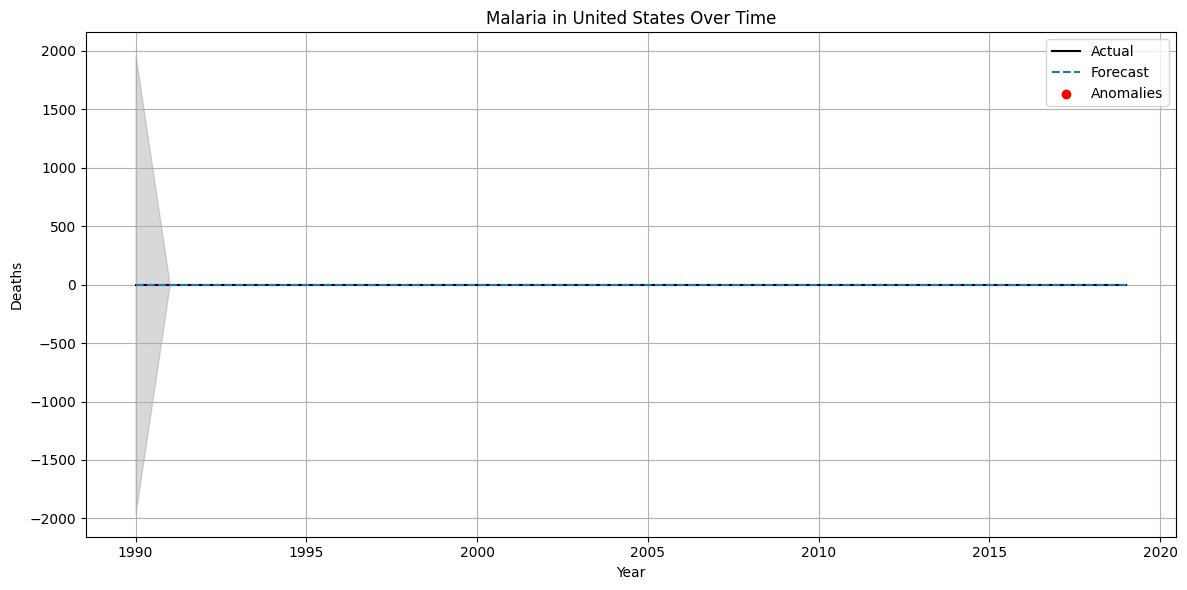

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(subset.index, subset['Deaths'], label='Actual', color='black')
plt.plot(subset.index, subset['Forecast'], label='Forecast', linestyle='--')
plt.fill_between(subset.index, subset['Lower'], subset['Upper'], color='gray', alpha=0.3)

# Highlight anomalies
anomalies = subset[subset['Anomaly']]
plt.scatter(anomalies.index, anomalies['Deaths'], color='red', label='Anomalies')

plt.title(f'{disease} in {country} Over Time')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
results_list = []

for country in tqdm(df['Country/Territory'].unique()):
    for disease in disease_cols:
        subset = df_long[(df_long['Country/Territory'] == country) & (df_long['Disease'] == disease)]
        subset = subset.sort_values('Year').set_index('Year')
        subset['Deaths'] = pd.to_numeric(subset['Deaths'], errors='coerce').fillna(0)

        if len(subset) < 10 or subset['Deaths'].sum() == 0:
            continue

        try:
            model = ARIMA(subset['Deaths'], order=(1,1,1))
            results = model.fit()
            forecast = results.get_prediction(start=0, end=len(subset)-1)
            conf_int = forecast.conf_int()
            forecast_mean = forecast.predicted_mean

            anomalies = ((subset['Deaths'] < conf_int.iloc[:,0]) |
                         (subset['Deaths'] > conf_int.iloc[:,1]))

            if anomalies.any():
                years = subset.index[anomalies].tolist()
                for y in years:
                    results_list.append({
                        'Country': country,
                        'Disease': disease,
                        'Year': y,
                        'Deaths': subset.loc[y, 'Deaths'],
                        'Lower': conf_int.loc[y].iloc[0],
                        'Upper': conf_int.loc[y].iloc[1]
                    })

        except:
            continue

anomalies_df = pd.DataFrame(results_list)
anomalies_df.head()

  0%|          | 0/204 [00:00<?, ?it/s]

,Country,Disease,Year,Deaths,Lower,Upper
0,Afghanistan,Meningitis,1990,2159,-1983.766573,1983.766573
1,Afghanistan,Meningitis,2003,3300,2692.859616,3203.911772
2,Afghanistan,Meningitis,2014,1935,2028.575328,2539.627484
3,Afghanistan,Alzheimer's Disease and Other Dementias,1995,1225,1226.092616,1242.509785
4,Afghanistan,Alzheimer's Disease and Other Dementias,2016,1690,1672.996914,1689.413876


In [10]:
from google.colab import files

anomalies_df.to_excel('anomalies_detected.xlsx', index=False)
files.download('anomalies_detected.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>